In [33]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import os
# os.chdir('D:/thesis_code/keypoint_matcher')
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

import numpy as np
import pandas as pd
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import math


# torch.set_float32_matmul_precision('medium')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.empty_cache()

# CSV Maker

In [35]:
threshold = 26
patch_size = 32

=> Error statistics:
{'count_above_threshold_target_error': 3006,
 'count_above_threshold_x': 2194,
 'count_above_threshold_y': 789,
 'max_reference_error': 336.12,
 'max_target_error': 514.73,
 'mean_reference_error': 22.89,
 'mean_target_error': 2.41,
 'median_reference_error': 17.67,
 'median_target_error': 0.86,
 'min_reference_error': 0.0,
 'min_target_error': 0.0,
 'std_dev_reference_error': 19.68,
 'std_dev_target_error': 7.43}
=> Estimate Accuracy percentages:
Accuracy within 90 pixels: 99.90%
Accuracy within 60 pixels: 99.69%
Accuracy within 30 pixels: 98.72%
Accuracy within 25 pixels: 98.32%
Accuracy within 5 pixels: 92.77%
Accuracy within 2 pixels: 79.56%
Accuracy within 1.5 pixels: 71.50%
Accuracy within 1.25 pixels: 65.22%
Accuracy within 1 pixels: 56.45%
=> Number of high-error rows per dataset:
dataset
MOO02_hand_puncher_2          1103
MOO04_hand_shooter_hard        862
MOO01_hand_puncher_1           580
MOO03_hand_shooter_easy        194
MOO06_inspect_hard             

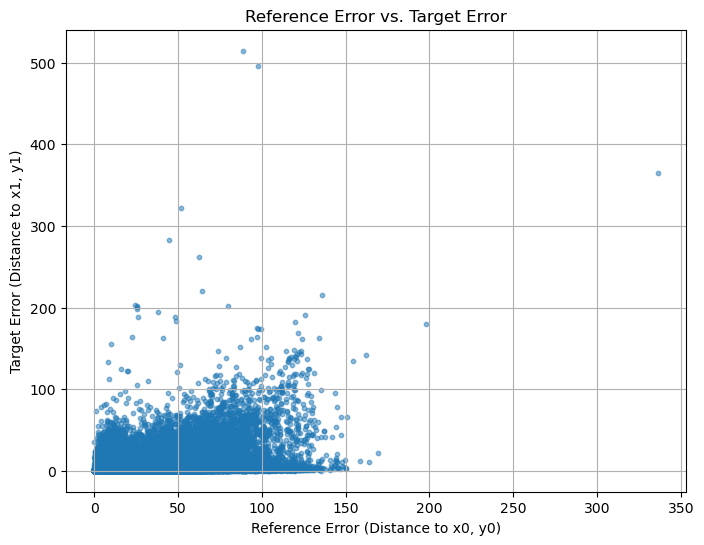

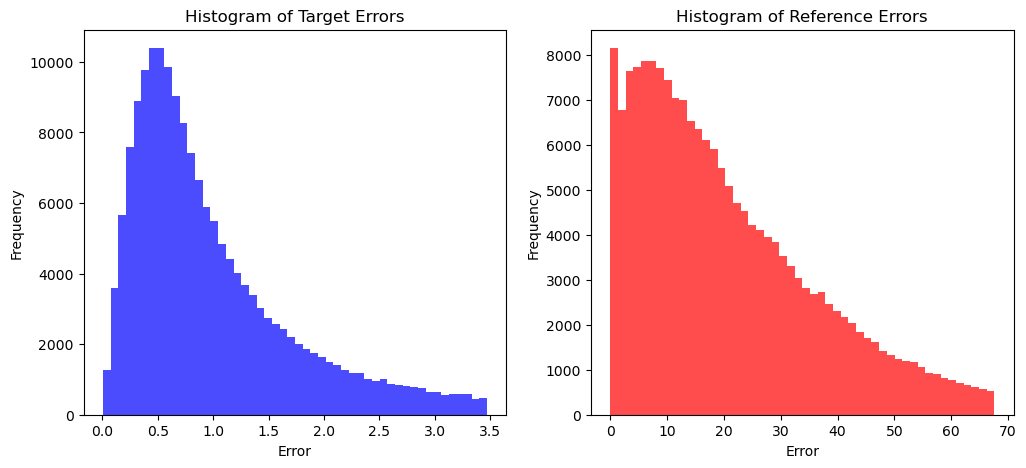

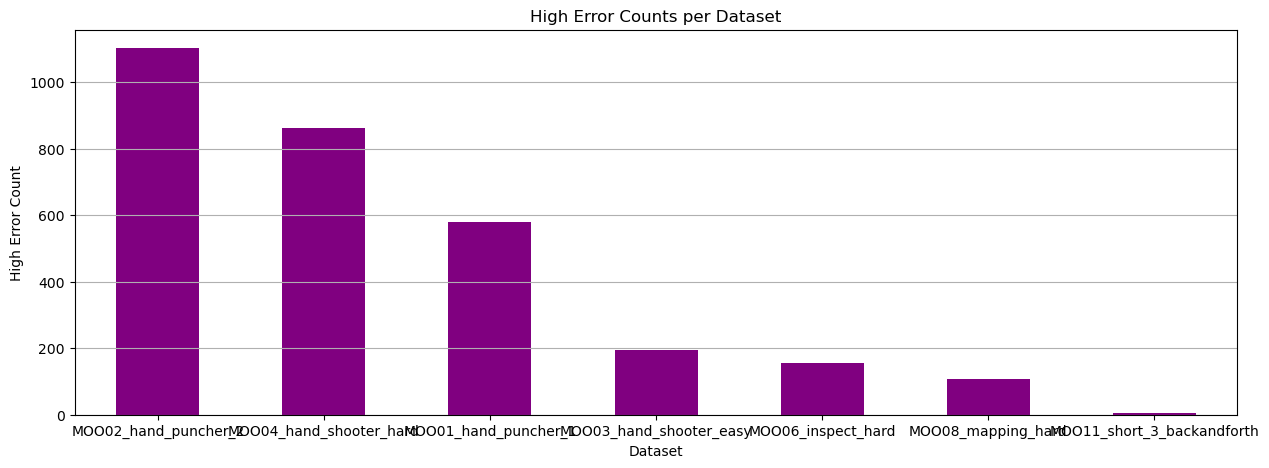

Done!


In [36]:
from prep_1_distance_to_target import main

main(threshold)

In [37]:
from prep_2_create_splits import main

main(threshold, patch_size)

len(training_df)=189119
len(clean_df)=180596
len(centered_df)=180596


/home/stud/ath/ath_ws/keypoint_matcher/prep_2_create_splits.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/stud/ath/ath_ws/keypoint_matcher/prep_2_create_splits.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_train_df.loc[:, "valid"] = True
/home/stud/ath/ath_ws/keypoint_matcher/prep_2_create_splits.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

Valid rows: 130696
Invalid rows: 0
=> Dataset Stats:
Train dataset size: 130696 (72.37%)
Validation dataset size: 48289 (26.74%)
Test dataset size: 1611 (0.89%)
Total cleaned dataset size: 180596 (100%)
Done!


In [38]:
import pandas as pd

csv_path = "/home/stud/ath/ath_ws/datasets/match_april/26_inline/train.csv"
df = pd.read_csv(csv_path)

# df[df["valid"] == False].head()

df.head()

,dataset,cam,kpid,pair_name,x0,y0,x1,y1,x_guess,y_guess,certainty,valid,x1_fake,y1_fake,x_guess_fake,y_guess_fake,certainty_fake
0,MOO01_hand_puncher_1,0,6.0,7465126824890_7465160114090,128.002899,76.029915,128.460968,76.379158,128.009567,76.006332,0.956268,True,82.734214,418.096713,82.734214,418.096713,0.0
1,MOO01_hand_puncher_1,0,16.0,7465126824890_7465160114090,233.753555,44.724400,233.604706,44.791782,233.759933,44.698345,0.217508,True,502.017815,219.196424,502.017815,219.196424,0.0
2,MOO01_hand_puncher_1,0,44.0,7465126824890_7465160114090,476.477448,43.833572,476.315216,43.603176,476.489258,43.797989,0.917963,True,74.474253,309.762028,74.474253,309.762028,0.0
3,MOO01_hand_puncher_1,0,52.0,7465126824890_7465160114090,557.045044,220.707291,557.698975,220.737442,557.065430,220.675842,0.755588,True,61.504901,427.828685,61.504901,427.828685,0.0
4,MOO01_hand_puncher_1,0,22.0,7465160114090_7465193409290,225.831238,320.724182,225.273132,320.661255,225.831604,320.697357,0.976537,True,395.923229,247.927171,395.923229,247.927171,0.0


In [41]:
df.columns

Index(['dataset', 'cam', 'kpid', 'pair_name', 'x0', 'y0', 'x1', 'y1',
       'x_guess', 'y_guess', 'certainty', 'valid', 'x1_fake', 'y1_fake',
       'x_guess_fake', 'y_guess_fake', 'certainty_fake'],
      dtype='object')

In [39]:
nan_exists = df.isnull().values.any() 
nan_exists

False

In [40]:
conf_threhold = 0.25
df[df['certainty'] > conf_threhold].shape, df[df['certainty'] <= conf_threhold].shape

((105019, 17), (25677, 17))